In [1]:
import pandas as pd
import numpy as np

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", "{:.2f}".format)

import seaborn as sns
import matplotlib.pyplot as plt

# CSV Exploration

## Patients

In [2]:
patients_df = pd.read_csv('../synthea_data/output/csv/patients.csv')
patients_df

,Id,BIRTHDATE,DEATHDATE,SSN,DRIVERS,PASSPORT,PREFIX,FIRST,MIDDLE,LAST,SUFFIX,MAIDEN,MARITAL,RACE,ETHNICITY,GENDER,BIRTHPLACE,ADDRESS,CITY,STATE,COUNTY,FIPS,ZIP,LAT,LON,HEALTHCARE_EXPENSES,HEALTHCARE_COVERAGE,INCOME
0,c44d667b-15d5-99d4-0f69-43ca66739022,1965-08-29,NaN,999-61-1158,S99942359,X90357234X,Mrs.,Azalee124,NaN,Rippin620,NaN,Streich926,D,white,nonhispanic,F,Hudson Massachusetts US,102 Conroy Camp,Webster,Massachusetts,Worcester County,25027.00,1570,42.05,-71.83,481568.96,242241.60,40621
1,51c5e2a9-2833-5133-b85a-329b9cd53c41,1986-01-22,NaN,999-92-7443,S99972916,X87842688X,Mr.,Merrill415,Bernard308,Johnson679,JD,NaN,D,white,nonhispanic,M,Saugus Massachusetts US,175 Walker Skyway Apt 94,Cochituate,Massachusetts,Middlesex County,NaN,0,42.28,-71.35,408183.15,293397.78,53297
2,502cf42a-a540-ff39-0d59-c10d7cc1f4c7,2007-04-16,NaN,999-84-7678,S99975791,NaN,Ms.,Aletha771,Isabell86,Ondricka197,NaN,NaN,NaN,white,nonhispanic,F,Cohasset Massachusetts US,234 Powlowski Loaf Suite 94,Belmont,Massachusetts,Middlesex County,25017.00,2138,42.36,-71.20,71276.61,538108.50,526968
3,02459150-c160-03b6-f1dd-dae8fd4b3e84,1970-04-25,NaN,999-14-5874,S99948951,X56279905X,Mrs.,Cathy455,NaN,Gleason633,NaN,Wintheiser220,M,white,nonhispanic,F,Northampton Massachusetts US,833 Rippin Lock Unit 28,Douglas,Massachusetts,Worcester County,NaN,0,42.07,-71.78,296834.71,1506701.17,168634
4,3237c17d-ea0b-90f4-0743-787ef29d2404,2025-01-11,NaN,999-94-6423,NaN,NaN,NaN,Zada604,Teisha100,Metz686,NaN,NaN,NaN,white,nonhispanic,F,Swansea Massachusetts US,696 Becker Wynd,North Adams,Massachusetts,Berkshire County,25003.00,1247,42.63,-73.13,500.00,5931.33,23153
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2333,213d3203-82da-c9e0-9186-840f582075bc,1925-01-21,1976-02-24,999-63-8604,S99971542,X57507989X,Mr.,Sterling124,Kraig824,Hauck852,NaN,NaN,D,black,nonhispanic,M,Lynn Massachusetts US,986 Emard Rue Suite 64,Boxford,Massachusetts,Essex County,25009.00,1921,42.73,-71.02,769574.90,0.00,113034
2334,803e8b31-ad2c-6c3a-c1be-de67544b6d2b,1925-01-21,1988-08-02,999-86-2819,S99933764,X37236096X,Mr.,Collin529,Willis868,O'Keefe54,NaN,NaN,D,black,nonhispanic,M,South Deerfield Massachusetts US,784 Schmeler Village Unit 41,Boxford,Massachusetts,Essex County,25009.00,1921,42.72,-70.99,294765.88,127376.51,113034
2335,b00222da-8016-b43b-10b0-818e19e8ed82,1925-01-21,2010-08-11,999-24-1845,S99937843,X72009102X,Mr.,Larry532,Judson999,Halvorson124,NaN,NaN,M,black,nonhispanic,M,Boston Massachusetts US,555 McGlynn Camp Unit 72,Boxford,Massachusetts,Essex County,25009.00,1921,42.72,-71.00,265298.29,168739.95,113034
2336,93adf52a-483e-ccb6-f8b3-a046e54372d6,1925-01-21,2014-05-23,999-50-6407,S99930251,X13054230X,Mr.,Wendell199,Bud153,Lowe577,NaN,NaN,M,black,nonhispanic,M,Abington Massachusetts US,788 Feil Station Unit 57,Boxford,Massachusetts,Essex County,25009.00,1921,42.72,-71.07,302942.75,141036.90,113034


- DRIVERS = drivers license
- FIPS = Federal Information Processing Standards code — it's a standardized numeric identifier for U.S. geographic areas (states, counties).  gives the county-level FIPS code for the patient's address — e.g. Massachusetts counties each have a unique 5-digit FIPS code (state code + county code). It's a normalized geography key, useful for joining against external census/demographic datasets

### Data quality

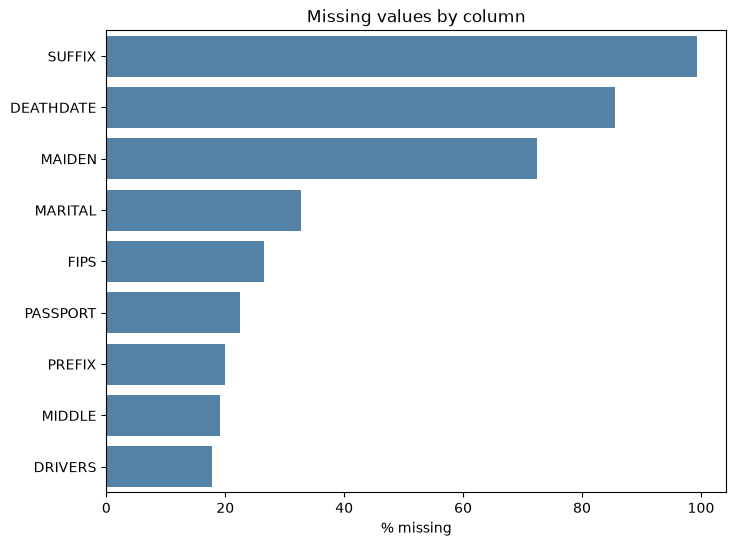

In [3]:
missing_pct = patients_df.isna().mean().sort_values(ascending=False)
missing_pct = (missing_pct[missing_pct > 0] * 100).round(1)

plt.figure(figsize=(8, 6))
sns.barplot(x=missing_pct.values, y=missing_pct.index, color="steelblue")
plt.xlabel("% missing")
plt.ylabel("")
plt.title("Missing values by column")
plt.show()

In [4]:
patients_df['MARITAL'].unique()

array(['D', nan, 'M', 'S', 'W'], dtype=object)

In [5]:
patients_df[patients_df['MARITAL'].isna()]['AGE'].describe()

KeyError: 'AGE'

In [6]:
plt.hist(patients_df[patients_df['MARITAL'].isna()]['AGE'])

KeyError: 'AGE'

- Most blanks in MARITAL are under the age of 28.

In [7]:
patients_df['BIRTHDATE'] = pd.to_datetime(patients_df['BIRTHDATE'])
patients_df['DEATHDATE'] = pd.to_datetime(patients_df['DEATHDATE'])

### Demographics

In [8]:
# AGE is current age for living patients, age-at-death for deceased ones — the two
# populations aren't directly comparable without the IS_DECEASED split above.
today = pd.Timestamp.today()
patients_df["IS_DECEASED"] = patients_df["DEATHDATE"].notna()
patients_df["AGE"] = ((patients_df["DEATHDATE"].fillna(today) - patients_df["BIRTHDATE"]).dt.days / 365.25)

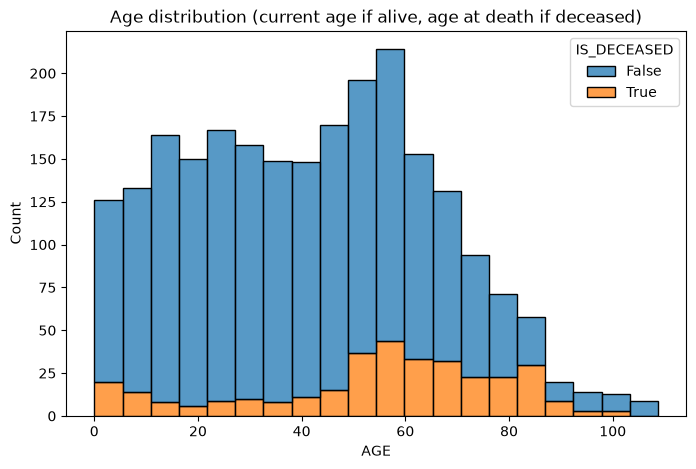

In [9]:
plt.figure(figsize=(8, 5))
sns.histplot(data=patients_df, x="AGE", hue="IS_DECEASED", multiple="stack", bins=20)
plt.title("Age distribution (current age if alive, age at death if deceased)")
plt.show()

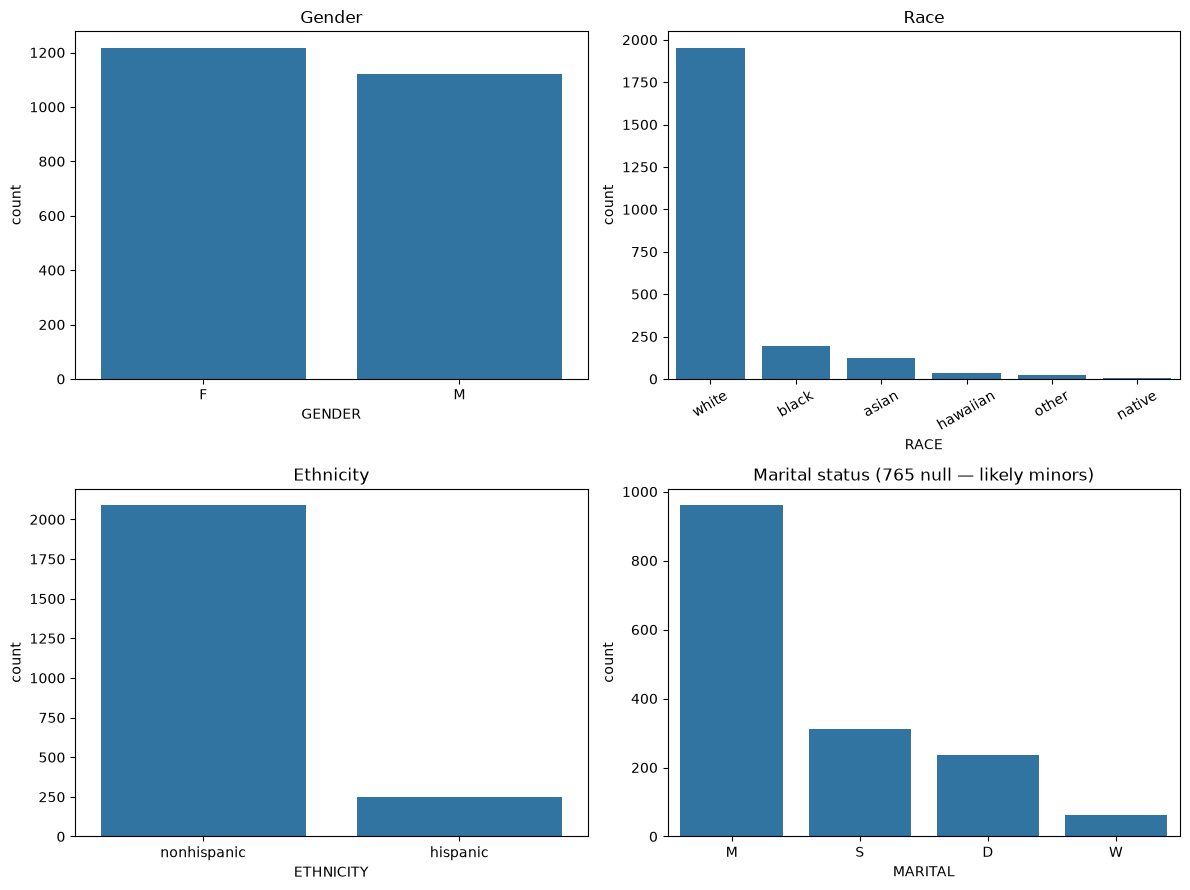

In [10]:
fig, axes = plt.subplots(2, 2, figsize=(12, 9))

sns.countplot(data=patients_df, x="GENDER", ax=axes[0, 0])
axes[0, 0].set_title("Gender")

sns.countplot(data=patients_df, x="RACE", ax=axes[0, 1], order=patients_df["RACE"].value_counts().index,)
axes[0, 1].set_title("Race")
axes[0, 1].tick_params(axis="x", rotation=30)

sns.countplot(data=patients_df, x="ETHNICITY", ax=axes[1, 0])
axes[1, 0].set_title("Ethnicity")

sns.countplot(data=patients_df, x="MARITAL", ax=axes[1, 1], order=patients_df["MARITAL"].value_counts().index,)
axes[1, 1].set_title(f"Marital status ({patients_df['MARITAL'].isna().sum()} null — likely minors)")

plt.tight_layout()
plt.show()

In [11]:
patients_df.describe()

,BIRTHDATE,DEATHDATE,FIPS,ZIP,LAT,LON,HEALTHCARE_EXPENSES,HEALTHCARE_COVERAGE,INCOME,AGE
count,2338,338,1716.00,2338.00,2338.00,2338.00,2338.00,2338.00,2338.00,2338.00
mean,1981-11-27 19:35:09.495295104,2007-03-24 04:02:50.414201088,25094.38,1456.79,42.26,-71.35,181684.99,349872.85,110768.84,41.96
min,1917-12-14 00:00:00,1946-05-20 00:00:00,25001.00,0.00,41.24,-73.34,100.00,0.00,13.00,0.02
25%,1963-12-19 12:00:00,1999-07-02 06:00:00,25011.00,0.00,42.12,-71.54,21624.21,20858.66,29988.25,22.16
50%,1981-11-19 00:00:00,2011-06-22 00:00:00,25017.00,1852.00,42.31,-71.14,93452.29,153750.30,70287.00,42.69
75%,2003-03-23 12:00:00,2019-10-20 18:00:00,25023.00,2150.75,42.45,-71.02,221527.34,551056.69,121828.50,59.22
max,2026-08-22 00:00:00,2026-08-20 00:00:00,44007.00,2861.00,42.88,-69.98,1640571.07,3848516.79,988857.00,108.73
std,NaN,NaN,1210.78,958.50,0.29,0.60,244955.48,470784.93,156519.27,23.82


### Socioeconomic

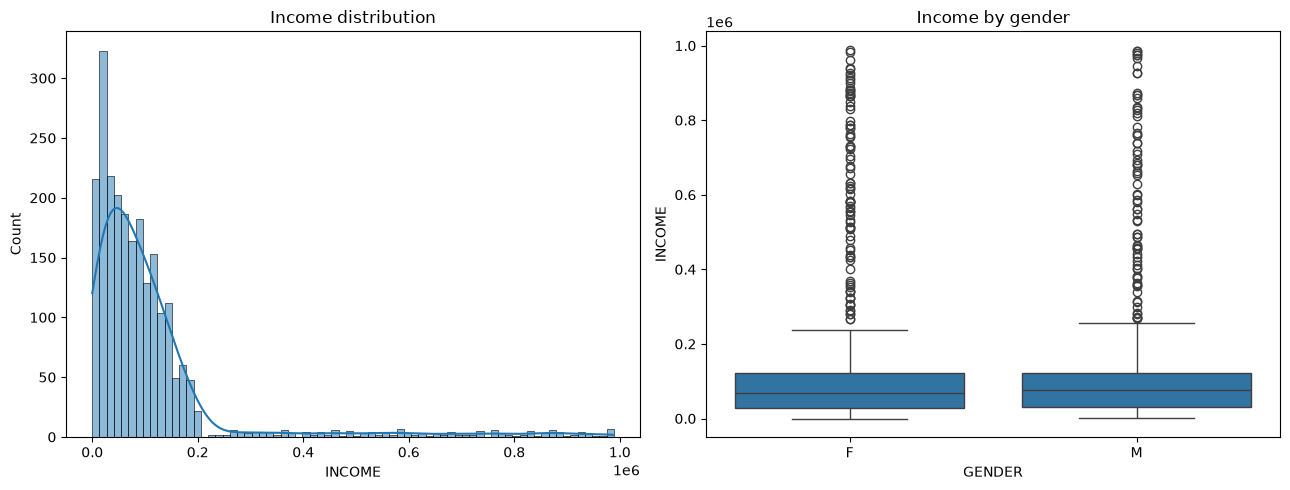

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

sns.histplot(data=patients_df, x="INCOME", kde=True, ax=axes[0])
axes[0].set_title("Income distribution")

sns.boxplot(data=patients_df, x="GENDER", y="INCOME", ax=axes[1])
axes[1].set_title("Income by gender")

plt.tight_layout()
plt.show()

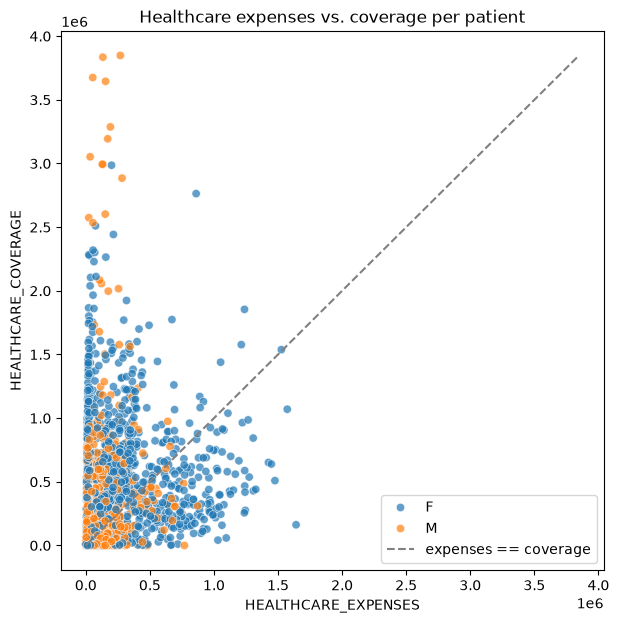

In [13]:
# negative == expenses exceed lifetime payer coverage (out-of-pocket burden);
# positive == coverage exceeds billed expenses (can happen with cumulative payer figures)
patients_df["OUT_OF_POCKET"] = patients_df["HEALTHCARE_EXPENSES"] - patients_df["HEALTHCARE_COVERAGE"]

plt.figure(figsize=(7, 7))
sns.scatterplot(
    data=patients_df, x="HEALTHCARE_EXPENSES", y="HEALTHCARE_COVERAGE",
    hue="GENDER", alpha=0.7,
)
lim = max(patients_df["HEALTHCARE_EXPENSES"].max(), patients_df["HEALTHCARE_COVERAGE"].max())
plt.plot([0, lim], [0, lim], linestyle="--", color="gray", label="expenses == coverage")
plt.legend()
plt.title("Healthcare expenses vs. coverage per patient")
plt.show()

### Geography

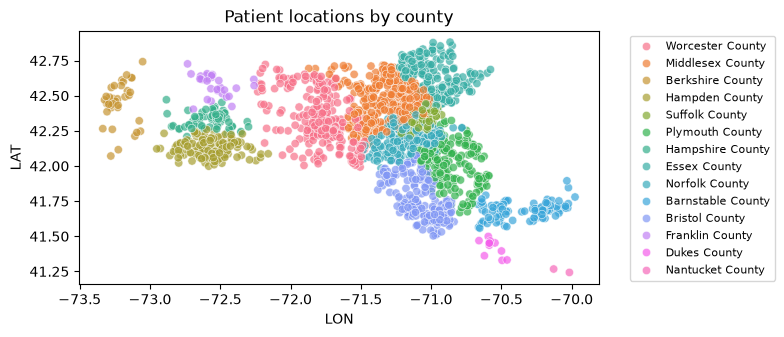

In [14]:
plt.figure(figsize=(8, 8))
sns.scatterplot(data=patients_df, x="LON", y="LAT", hue="COUNTY", alpha=0.7)
plt.gca().set_aspect("equal")  # equal degrees on both axes so the point cloud isn't visually stretched
plt.title("Patient locations by county")
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left", fontsize=8)
plt.tight_layout()
plt.show()

### EDA summary — key insights

- **2,338 patients, 338 deceased (~14%)** — `IS_DECEASED` should gate any age/expense analysis that shouldn't mix "current age" with "age at death."
- **Income is heavily right-skewed**: mean (\$111k) is well above the median (\$70k), pulled up by a max of \$989k. Prefer median over mean when summarizing income for a patient population.
- **`HEALTHCARE_COVERAGE`'s mean (\$350k) exceeds `HEALTHCARE_EXPENSES`'s mean (\$182k)**, and coverage's max (\$3.85M) dwarfs expenses' max (\$1.64M) — coverage is not a simple fraction of expenses in this dataset. Any "out-of-pocket" derivation (`EXPENSES - COVERAGE`) can go negative; treat it as a lifetime-cumulative payer figure, not a per-claim reimbursement.
- **`FIPS` is missing for 622/2,338 patients (~27%)**, all with `ZIP == 0` — a real gap tied to specific under-specified addresses, not random. Don't join on `FIPS` without checking for these rows.
- **`MARITAL` is null for 765/2,338 patients (~33%)** — almost certainly patients too young to have a marital status recorded, not missing data. Worth confirming against `AGE` before treating it as a data quality issue.
- **Patients cluster geographically by county** (see LAT/LON plot) — consistent with Synthea generating populations from fixed regional city/town seeds rather than a uniform spatial distribution across Massachusetts.

## Encounters

One row per clinical visit. Every clinical-event table (conditions, observations, medications, etc.) hangs off ENCOUNTER.

**Cost columns**
- BASE_ENCOUNTER_COST: flat facility fee for the encounter type (e.g. an ambulatory visit is always ~$85.55), independent of what happens during the visit.
- TOTAL_CLAIM_COST: everything billed for the encounter - the base fee plus every procedure, medication, immunization, device, etc. performed during it. Can run far above BASE_ENCOUNTER_COST.
- PAYER_COVERAGE: how much of TOTAL_CLAIM_COST the payer (insurer) actually covered. TOTAL_CLAIM_COST - PAYER_COVERAGE is the patient out-of-pocket cost for that encounter.

**ENCOUNTERCLASS values**
- ambulatory: non-admitted healthcare visit (you receive care without being admitted to a hospital)
- outpatient: a type of ambulatory care - a scheduled/planned service at a facility, same-day
- wellness: routine checkup / preventive visit
- inpatient: admitted, overnight-or-longer hospital stay
- emergency: ER visit
- urgentcare: walk-in urgent care clinic visit
- snf: skilled nursing facility care (post-acute recovery/rehab)
- hospice: end-of-life care
- home: care delivered at the patient's home
- virtual: telemedicine/remote visit

In [15]:
encounters_df = pd.read_csv('../synthea_data/output/csv/encounters.csv')
encounters_df

,Id,START,STOP,PATIENT,ORGANIZATION,PROVIDER,PAYER,ENCOUNTERCLASS,CODE,DESCRIPTION,BASE_ENCOUNTER_COST,TOTAL_CLAIM_COST,PAYER_COVERAGE,REASONCODE,REASONDESCRIPTION
0,c44d667b-15d5-99d4-9dc3-bb2d895495b9,1981-10-11T00:41:04Z,1981-10-11T01:06:02Z,c44d667b-15d5-99d4-0f69-43ca66739022,4ff8b164-4cf5-3ab4-b0f2-7ce8fda920e5,3166bff6-ecf5-3796-84c2-f3d90ffcd5ea,e03e23c9-4df1-3eb6-a62d-f70f02301496,wellness,410620009,Well child visit (procedure),136.80,1011.38,0.00,NaN,NaN
1,c44d667b-15d5-99d4-718f-134336f41a28,1983-10-23T00:41:04Z,1983-10-23T01:11:48Z,c44d667b-15d5-99d4-0f69-43ca66739022,4ff8b164-4cf5-3ab4-b0f2-7ce8fda920e5,3166bff6-ecf5-3796-84c2-f3d90ffcd5ea,e03e23c9-4df1-3eb6-a62d-f70f02301496,wellness,162673000,General examination of patient (procedure),136.80,1164.96,0.00,NaN,NaN
2,c44d667b-15d5-99d4-2c91-9fd0d8e38b98,1984-10-28T00:41:04Z,1984-10-28T01:16:53Z,c44d667b-15d5-99d4-0f69-43ca66739022,4ff8b164-4cf5-3ab4-b0f2-7ce8fda920e5,3166bff6-ecf5-3796-84c2-f3d90ffcd5ea,e03e23c9-4df1-3eb6-a62d-f70f02301496,wellness,162673000,General examination of patient (procedure),136.80,704.20,0.00,NaN,NaN
3,c44d667b-15d5-99d4-6280-d38ed9b4e5ac,1989-12-08T00:41:04Z,1989-12-08T00:56:04Z,c44d667b-15d5-99d4-0f69-43ca66739022,a2a41caf-758f-3962-8e5f-e6e603f93d17,de74b4c1-1b6d-3cc5-8d97-4b9d444a6748,e03e23c9-4df1-3eb6-a62d-f70f02301496,ambulatory,185345009,Encounter for symptom (procedure),85.55,92.93,0.00,75498004.00,Acute bacterial sinusitis (disorder)
4,c44d667b-15d5-99d4-db0e-663f459a4c7e,1997-07-10T00:41:04Z,1997-07-10T00:56:04Z,c44d667b-15d5-99d4-0f69-43ca66739022,a2a41caf-758f-3962-8e5f-e6e603f93d17,de74b4c1-1b6d-3cc5-8d97-4b9d444a6748,e03e23c9-4df1-3eb6-a62d-f70f02301496,ambulatory,424619006,Prenatal visit (regime/therapy),142.58,1005.38,0.00,156073000.00,Complete miscarriage (disorder)
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
138206,502dc964-df3b-7fa0-73ee-dbf877415a99,2025-12-14T01:10:17Z,2025-12-14T04:17:29Z,502dc964-df3b-7fa0-689e-78d3809a8df5,440fa4b8-c731-3cf5-81d9-aa3f30a37b95,5cdeccb6-c568-3206-b830-681487798473,a735bf55-83e9-331a-899d-a82a60b9f60c,ambulatory,185349003,Encounter for check up (procedure),85.55,3536.75,2829.40,103697008.00,Patient referral for dental care (procedure)
138207,502dc964-df3b-7fa0-fdd6-eba7b837e886,2025-12-21T01:10:17Z,2025-12-30T01:25:17Z,502dc964-df3b-7fa0-689e-78d3809a8df5,2e73956a-942f-36f3-b88c-f88e782e578f,941421d9-3343-3ad6-8e5b-31b1a806dd10,a735bf55-83e9-331a-899d-a82a60b9f60c,hospice,305336008,Admission to hospice (procedure),137.53,6177.13,4755.30,26929004.00,Alzheimer's disease (disorder)
138208,502dc964-df3b-7fa0-d044-a77766f658cb,2026-01-04T01:10:17Z,2026-01-04T01:25:17Z,502dc964-df3b-7fa0-689e-78d3809a8df5,440fa4b8-c731-3cf5-81d9-aa3f30a37b95,5cdeccb6-c568-3206-b830-681487798473,a735bf55-83e9-331a-899d-a82a60b9f60c,ambulatory,185345009,Encounter for symptom (procedure),85.55,85.55,68.44,444814009.00,Viral sinusitis (disorder)
138209,502dc964-df3b-7fa0-c09f-28f35610826e,2026-07-05T01:10:17Z,2026-07-05T01:47:54Z,502dc964-df3b-7fa0-689e-78d3809a8df5,7a75decf-7d3f-3b0d-8c2b-3abf0a8c7f58,9ecd2ae1-2878-3a54-93c2-ae106786378e,a735bf55-83e9-331a-899d-a82a60b9f60c,wellness,162673000,General examination of patient (procedure),136.80,919.90,735.92,NaN,NaN


### Data quality

In [16]:
encounters_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 138211 entries, 0 to 138210
Data columns (total 15 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   Id                   138211 non-null  object 
 1   START                138211 non-null  object 
 2   STOP                 138211 non-null  object 
 3   PATIENT              138211 non-null  object 
 4   ORGANIZATION         138211 non-null  object 
 5   PROVIDER             138211 non-null  object 
 6   PAYER                138211 non-null  object 
 7   ENCOUNTERCLASS       138211 non-null  object 
 8   CODE                 138211 non-null  int64  
 9   DESCRIPTION          138211 non-null  object 
 10  BASE_ENCOUNTER_COST  138211 non-null  float64
 11  TOTAL_CLAIM_COST     138211 non-null  float64
 12  PAYER_COVERAGE       138211 non-null  float64
 13  REASONCODE           87156 non-null   float64
 14  REASONDESCRIPTION    87156 non-null   object 
dtypes: float64(4), in

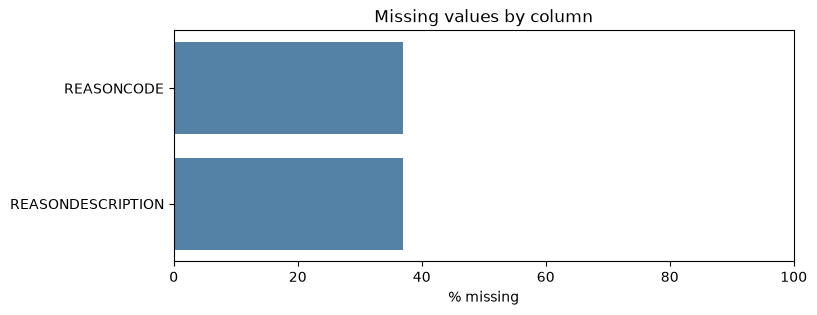

In [17]:
missing_pct = encounters_df.isna().mean().sort_values(ascending=False)
missing_pct = (missing_pct[missing_pct > 0] * 100).round(1)

plt.figure(figsize=(8, 3))
sns.barplot(x=missing_pct.values, y=missing_pct.index, color="steelblue")
plt.xlabel("% missing")
plt.xlim(0, 100)
plt.ylabel("")
plt.title("Missing values by column")
plt.show()

In [18]:
encounters_df['START'] = pd.to_datetime(encounters_df['START'])
encounters_df['STOP'] = pd.to_datetime(encounters_df['STOP'])
encounters_df['DURATION_MIN'] = (encounters_df['STOP'] - encounters_df['START']).dt.total_seconds() / 60

print('Non-positive duration rows:', (encounters_df['DURATION_MIN'] <= 0).sum())
encounters_df['DURATION_MIN'].describe()

Non-positive duration rows: 0


count   138211.00
mean       367.34
std       3167.73
min         15.00
25%         15.00
50%         45.57
75%        149.00
max     169130.00
Name: DURATION_MIN, dtype: float64

### Encounter classes

In [19]:
encounters_df.groupby('ENCOUNTERCLASS').size().reset_index(name='COUNT').sort_values(by='COUNT', ascending=False)

,ENCOUNTERCLASS,COUNT
0,ambulatory,76216
9,wellness,28666
5,outpatient,18262
7,urgentcare,6059
1,emergency,4836
4,inpatient,2433
2,home,682
3,hospice,366
8,virtual,361
6,snf,330


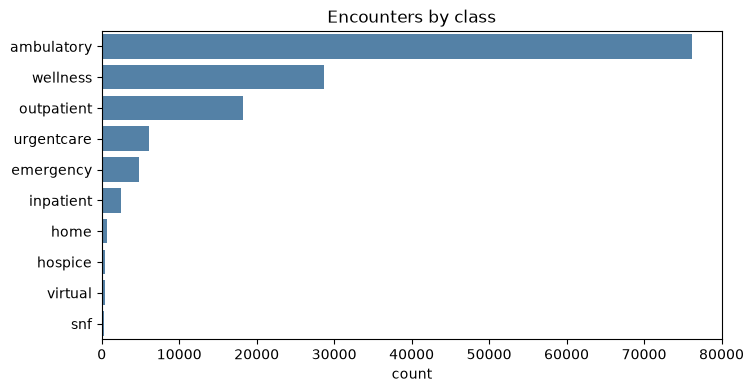

In [20]:
plt.figure(figsize=(8, 4))
order = encounters_df['ENCOUNTERCLASS'].value_counts().index
sns.countplot(data=encounters_df, y='ENCOUNTERCLASS', order=order, color='steelblue')
plt.title('Encounters by class')
plt.xlabel('count')
plt.ylabel('')
plt.show()

In [21]:
encounters_df.groupby(['CODE', 'DESCRIPTION']).size().reset_index(name='COUNT').sort_values(by='COUNT', ascending=False).reset_index(drop=True)

,CODE,DESCRIPTION,COUNT
0,185347001,Encounter for problem (procedure),36506
1,185349003,Encounter for check up (procedure),23078
2,162673000,General examination of patient (procedure),20790
3,185345009,Encounter for symptom (procedure),7731
4,410620009,Well child visit (procedure),7547
5,702927004,Urgent care clinic (environment),6020
6,424619006,Prenatal visit (regime/therapy),5771
7,308335008,Patient encounter procedure (procedure),4461
8,50849002,Emergency room admission (procedure),3630
9,390906007,Follow-up encounter (procedure),3391


In [22]:
enc_grouped = encounters_df.groupby(['ENCOUNTERCLASS', 'DESCRIPTION']).size().reset_index(name='COUNT')
enc_grouped.sort_values(['ENCOUNTERCLASS', 'COUNT'], ascending=[True, False]).reset_index(drop=True)

,ENCOUNTERCLASS,DESCRIPTION,COUNT
0,ambulatory,Encounter for problem (procedure),34626
1,ambulatory,Encounter for check up (procedure),14886
2,ambulatory,Encounter for symptom (procedure),7250
3,ambulatory,Prenatal visit (regime/therapy),5771
4,ambulatory,Follow-up encounter (procedure),3348
...,...,...,...
73,virtual,Discussion about treatment (procedure),1
74,wellness,General examination of patient (procedure),20790
75,wellness,Well child visit (procedure),7547
76,wellness,Death Certification,320


In [23]:
enc_grouped[enc_grouped['ENCOUNTERCLASS'] == 'ambulatory'].sort_values('COUNT', ascending=False)

,ENCOUNTERCLASS,DESCRIPTION,COUNT
6,ambulatory,Encounter for problem (procedure),34626
5,ambulatory,Encounter for check up (procedure),14886
7,ambulatory,Encounter for symptom (procedure),7250
24,ambulatory,Prenatal visit (regime/therapy),5771
9,ambulatory,Follow-up encounter (procedure),3348
15,ambulatory,Outpatient procedure (procedure),2621
27,ambulatory,Telemedicine consultation with patient (proced...,1819
14,ambulatory,Ophthalmic examination and evaluation (procedure),1460
23,ambulatory,Prenatal initial visit (regime/therapy),1034
21,ambulatory,Postoperative follow-up visit (procedure),659


### Costs & payer coverage

- PAYER_COVERAGE is how much of that specific encounter's TOTAL_CLAIM_COST the patient's payer (insurer) actually covered - i.e. the reimbursed portion. The difference TOTAL_CLAIM_COST - PAYER_COVERAGE is the patient's out-of-pocket cost for that encounter.
- BASE_ENCOUNTER_COST is just the flat visit/facility fee for that encounter type - a fixed rate tied to ENCOUNTERCLASS/CODE (e.g. "ambulatory visit" always costs $85.55 as a base fee, regardless of what happens during it). TOTAL_CLAIM_COST also bills every procedure/medication/etc. performed at the visit, so it can run far higher than the base fee.

In [24]:
encounters_df[['BASE_ENCOUNTER_COST', 'TOTAL_CLAIM_COST', 'PAYER_COVERAGE']].describe()

,BASE_ENCOUNTER_COST,TOTAL_CLAIM_COST,PAYER_COVERAGE
count,138211.00,138211.00,138211.00
mean,111.95,2800.89,2066.90
std,27.38,7441.37,6409.15
min,75.00,75.00,0.00
25%,85.55,535.87,0.00
50%,85.55,919.90,500.87
75%,142.58,2114.98,1364.03
max,146.18,317643.54,254114.50


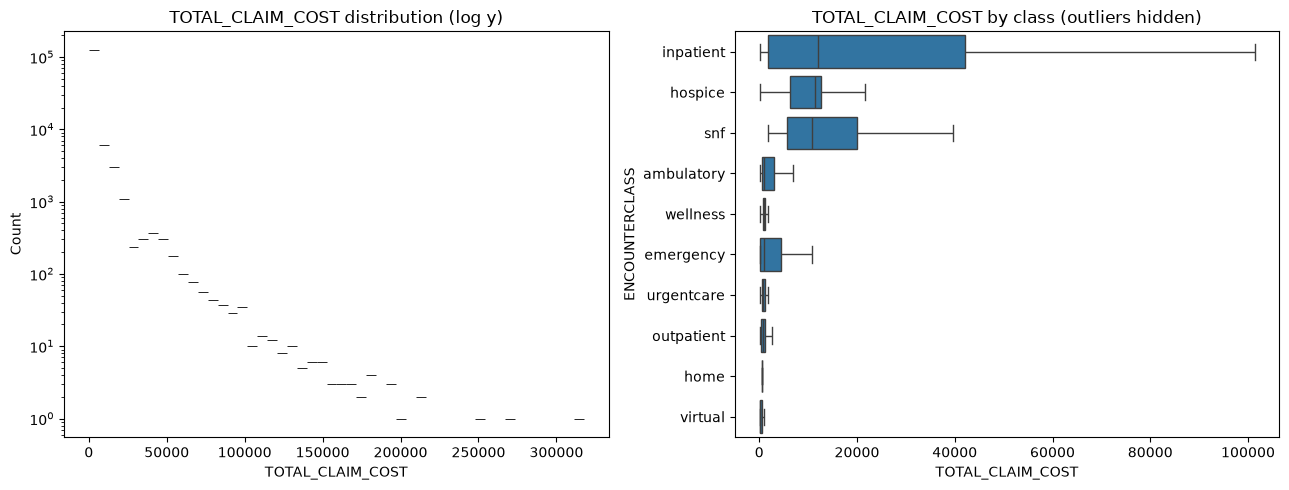

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

sns.histplot(encounters_df['TOTAL_CLAIM_COST'], bins=50, log_scale=(False, True), ax=axes[0])
axes[0].set_title('TOTAL_CLAIM_COST distribution (log y)')

order = encounters_df.groupby('ENCOUNTERCLASS')['TOTAL_CLAIM_COST'].median().sort_values(ascending=False).index
sns.boxplot(data=encounters_df, x='TOTAL_CLAIM_COST', y='ENCOUNTERCLASS', order=order, ax=axes[1], showfliers=False)
axes[1].set_title('TOTAL_CLAIM_COST by class (outliers hidden)')

plt.tight_layout()
plt.show()

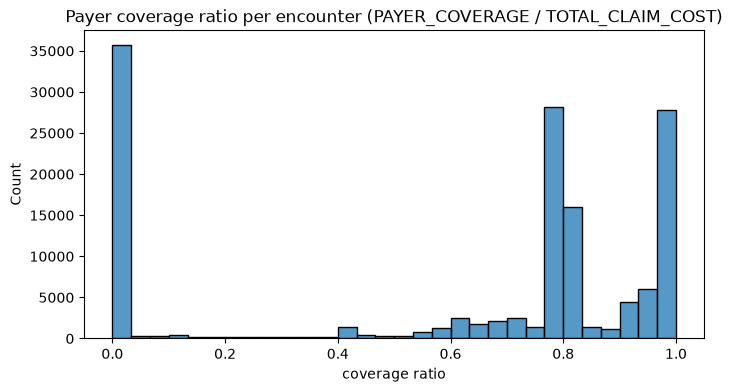

count   138211.00
mean         0.61
std          0.39
min          0.00
25%          0.00
50%          0.80
75%          0.93
max          1.00
Name: COVERAGE_RATIO, dtype: float64

In [26]:
# coverage ratio undefined (0/0) when TOTAL_CLAIM_COST is 0 - exclude those rather than treat as 0% covered
priced = encounters_df[encounters_df['TOTAL_CLAIM_COST'] > 0].copy()
priced['COVERAGE_RATIO'] = priced['PAYER_COVERAGE'] / priced['TOTAL_CLAIM_COST']

plt.figure(figsize=(8, 4))
sns.histplot(priced['COVERAGE_RATIO'], bins=30)
plt.title('Payer coverage ratio per encounter (PAYER_COVERAGE / TOTAL_CLAIM_COST)')
plt.xlabel('coverage ratio')
plt.show()

priced['COVERAGE_RATIO'].describe()

### Encounters per patient & over time

In [27]:
enc_per_patient = encounters_df.groupby('PATIENT').size()
enc_per_patient.describe()

count   2338.00
mean      59.12
std       90.80
min        1.00
25%       24.00
50%       36.00
75%       58.00
max      947.00
dtype: float64

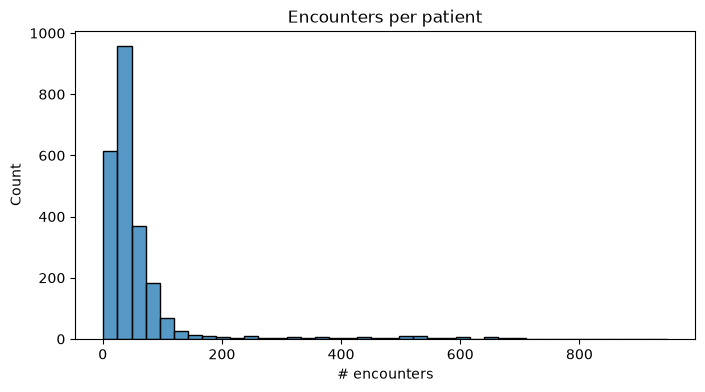

In [28]:
plt.figure(figsize=(8, 4))
sns.histplot(enc_per_patient, bins=40)
plt.title('Encounters per patient')
plt.xlabel('# encounters')
plt.show()

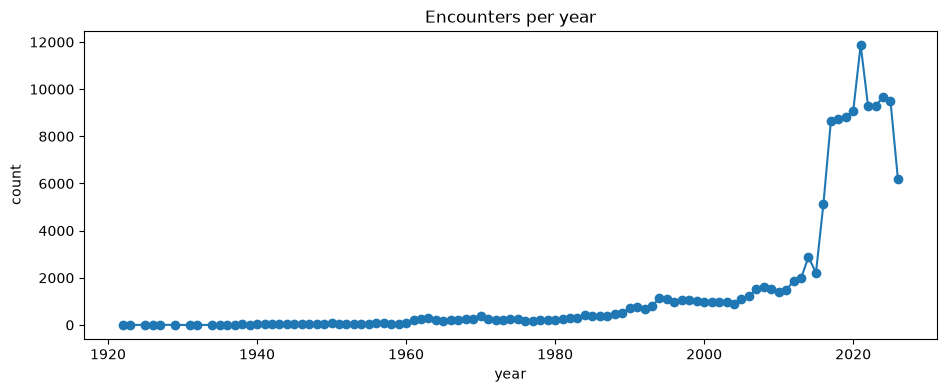

In [29]:
# 2026 is a partial year (data generated mid-year) - expect a dip, not a real trend reversal
yearly = encounters_df['START'].dt.year.value_counts().sort_index()

plt.figure(figsize=(11, 4))
yearly.plot(kind='line', marker='o')
plt.title('Encounters per year')
plt.xlabel('year')
plt.ylabel('count')
plt.show()

### Reason codes

In [30]:
has_reason = encounters_df['REASONCODE'].notna()
print(f'Overall: {has_reason.mean():.1%} of encounters carry a REASONCODE')
encounters_df.groupby('ENCOUNTERCLASS')['REASONCODE'].apply(lambda s: s.notna().mean()).sort_values(ascending=False).rename('PCT_WITH_REASON').round(3)

Overall: 63.1% of encounters carry a REASONCODE


ENCOUNTERCLASS
inpatient    1.00
home         1.00
snf          1.00
ambulatory   0.94
virtual      0.91
emergency    0.78
hospice      0.77
outpatient   0.40
wellness     0.01
urgentcare   0.01
Name: PCT_WITH_REASON, dtype: float64

In [31]:
encounters_df['REASONDESCRIPTION'].value_counts().head(15)

REASONDESCRIPTION
Chronic kidney disease stage 4 (disorder)       16691
End-stage renal disease (disorder)               7539
Normal pregnancy (finding)                       7128
Patient referral for dental care (procedure)     6756
Contraception care (regime/therapy)              6359
Gingivitis (disorder)                            6242
Dependent drug abuse (disorder)                  3815
Allergic disposition (finding)                   3130
Chronic congestive heart failure (disorder)      2539
Viral sinusitis (disorder)                       2430
Hyperlipidemia (disorder)                        2007
Chronic pain (finding)                           1461
Acute viral pharyngitis (disorder)               1391
Acute bronchitis (disorder)                      1228
Malignant neoplasm of breast (disorder)          1139
Name: count, dtype: int64

### EDA summary - key insights

- **REASONCODE/REASONDESCRIPTION are the only columns with nulls (36.9% missing)** - and it is structural, not random: `inpatient`, `home`, and `snf` encounters are 100% reasoned, `ambulatory` 94%, but `wellness` (1%) and `urgentcare` (1%) are almost never reasoned. Checkups and urgent-care visits do not carry a formal SNOMED reason code in this dataset - do not treat their missing REASONCODE as a data quality gap.
- **`ambulatory` (76,216) and `wellness` (28,666) dominate encounter volume** - together ~76% of all 138,211 encounters. `snf`/`hospice`/`virtual` are each under 400 rows; any per-class model or aggregate will be noisy for those classes at this population size.
- **`TOTAL_CLAIM_COST` is extremely right-skewed**: median $919.90 vs. mean $2,800.89 vs. max $317,643.54 (std $7,441 - larger than the mean). Always summarize with median/IQR, not mean, and use a log scale to visualize it.
- **Payer coverage ratio is bimodal, not a smooth distribution**: 0% at the 25th percentile but 80-93%+ from the median up - many encounters are billed with zero payer contribution (self-pay / pre-coverage / no-charge visit types) while the rest cluster near full reimbursement. A single "average coverage %" number would misrepresent this.
- **`DURATION_MIN` has a 15-minute floor and a 169,130-minute (~117 day) max** - no zero/negative durations, so START/STOP are internally consistent, but the extreme long tail (mean 367 min vs. median 45.6 min) is almost certainly multi-day `inpatient`/`snf`/`hospice` stays; filter or log-transform before using duration as a feature.
- **Encounters per patient range 1-947 (median 36, mean 59)** - heavily skewed by a handful of high-utilization patients (chronic disease / frequent dialysis, consistent with the top REASONDESCRIPTION values below). Per-patient aggregates should use median or cap outliers.
- **Top REASONDESCRIPTION values are dominated by chronic/recurring conditions**: Chronic kidney disease stage 4 (16,691), End-stage renal disease (7,539), Normal pregnancy (7,128), dental/contraception referrals, gingivitis. This is exactly the CKD/renal-failure population that backs the anchor "why did creatinine double" scenario - confirms there is enough encounter density around kidney disease to support that investigation.
- **2026 shows a dip in the yearly encounter trend** - expected, not a real drop: the data was generated mid-2026, so that year is a partial-year count, not a completed one.


## Organizations

Healthcare facilities/organizations. Every encounter FKs into this table via `ORGANIZATION`.

**UTILIZATION**: Synthea-generated counter meant to represent how many encounters have been billed through that organization. It's a synthetic proxy, not a real capacity metric - we cross-check it against actual encounter counts below rather than trusting it at face value.

In [74]:
organizations_df = pd.read_csv('../synthea_data/output/csv/organizations.csv')
organizations_df.head()

,Id,NAME,ADDRESS,CITY,STATE,ZIP,LAT,LON,PHONE,REVENUE,UTILIZATION
0,74ab949d-17ac-3309-83a0-13b4405c66aa,Fitchburg Outpatient Clinic,881 Main Street,Fitchburg,MA,1420,42.59,-71.81,978-342-9781 Or 978-342-9781,0.00,5527
1,da92d3fc-5445-3825-a937-043ef0d6ecd0,TRINITY HOME CARE INC.,336 GRATTAN ST,CHICOPEE,MA,10201314,42.17,-72.59,4033313294,0.00,96
2,588f6ce6-b8db-3588-8189-29db2680a313,BOSTON HEALTH CARE FOR THE HOMELESS PROGRAM INC,461 WALNUT AVE,JAMAICA PLAIN,MA,21302331,42.31,-71.10,8576541550,0.00,148
3,324b4137-57a0-3ae0-89db-1c33f57ae0c1,LOWN ACQUISITION LLC,134 NORTH ST,NORTH READING,MA,18641315,42.59,-71.11,7818262393,0.00,2
4,b6398e07-4967-31a5-807f-380039a1f303,EDWARD M KENNEDY COMMUNITY HEALTH CENTER INC,19 TACOMA ST,WORCESTER,MA,16053516,42.30,-71.77,5088521805,0.00,85


### Data quality

In [75]:
organizations_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 959 entries, 0 to 958
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Id           959 non-null    object 
 1   NAME         959 non-null    object 
 2   ADDRESS      959 non-null    object 
 3   CITY         959 non-null    object 
 4   STATE        959 non-null    object 
 5   ZIP          959 non-null    int64  
 6   LAT          959 non-null    float64
 7   LON          959 non-null    float64
 8   PHONE        959 non-null    object 
 9   REVENUE      959 non-null    float64
 10  UTILIZATION  959 non-null    int64  
dtypes: float64(3), int64(2), object(6)
memory usage: 82.5+ KB


In [76]:
dupe_ids = organizations_df['Id'].duplicated().sum()
print('Duplicate Id rows:', dupe_ids)
print('Unique orgs:', organizations_df['Id'].nunique(), '/', len(organizations_df))

Duplicate Id rows: 0
Unique orgs: 959 / 959


### Revenue & utilization

In [77]:
organizations_df[['REVENUE', 'UTILIZATION']].describe()

,REVENUE,UTILIZATION
count,959.00,959.00
mean,0.00,400.48
std,0.00,871.22
min,0.00,1.00
25%,0.00,14.00
50%,0.00,94.00
75%,0.00,335.50
max,0.00,9881.00


In [78]:
print('REVENUE == 0:', (organizations_df['REVENUE'] == 0).sum(), '/', len(organizations_df))
print('REVENUE unique values:', organizations_df['REVENUE'].nunique())

REVENUE == 0: 959 / 959
REVENUE unique values: 1


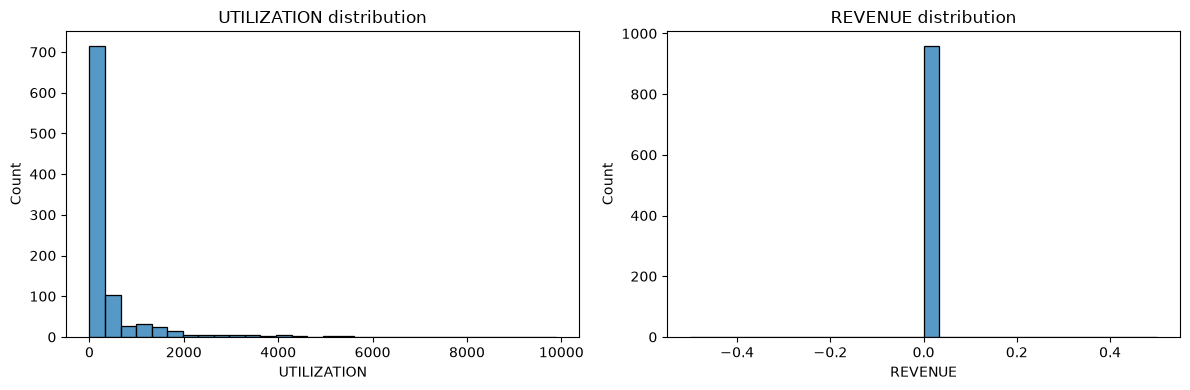

In [79]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(organizations_df['UTILIZATION'], bins=30, ax=ax[0])
ax[0].set_title('UTILIZATION distribution')
sns.histplot(organizations_df['REVENUE'], bins=30, ax=ax[1])
ax[1].set_title('REVENUE distribution')
plt.tight_layout()
plt.show()

### Geographic distribution

In [80]:
state_counts = organizations_df['STATE'].value_counts()
city_counts = organizations_df['CITY'].value_counts()
print('States:', state_counts.to_dict())
city_counts.head(10)

States: {'MA': 959}


CITY
WORCESTER        49
BOSTON           29
FALL RIVER       18
SPRINGFIELD      15
QUINCY           15
NORWOOD          14
BROCKTON         14
PLYMOUTH         13
PITTSFIELD       13
NORTH ANDOVER    13
Name: count, dtype: int64

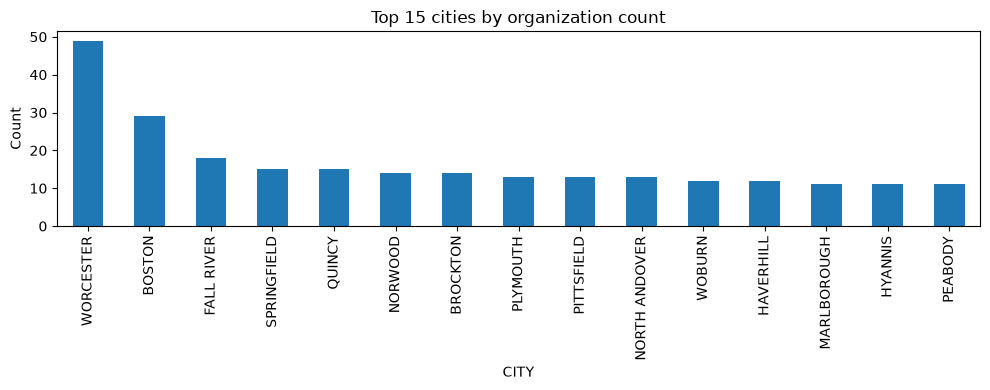

In [81]:
plt.figure(figsize=(10, 4))
city_counts.head(15).plot(kind='bar')
plt.title('Top 15 cities by organization count')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

### Referential integrity: organizations vs encounters

In [82]:
org_ids = set(organizations_df['Id'])
enc_org_ids = set(encounters_df['ORGANIZATION'])

print('Orgs referenced by encounters but missing from organizations_df:', len(enc_org_ids - org_ids))
print('Orgs in organizations_df with zero encounters:', len(org_ids - enc_org_ids), '/', len(org_ids))

Orgs referenced by encounters but missing from organizations_df: 0
Orgs in organizations_df with zero encounters: 87 / 959


### Utilization sanity check

Does the `UTILIZATION` column actually match real encounter counts per organization?

In [83]:
org_counts = encounters_df.groupby('ORGANIZATION').size().reset_index(name='COUNT')

util_check = organizations_df[['Id', 'NAME', 'UTILIZATION']].merge(
    org_counts, left_on='Id', right_on='ORGANIZATION', how='left'
)
util_check['COUNT'] = util_check['COUNT'].fillna(0)

mismatches = (util_check['UTILIZATION'] != util_check['COUNT']).sum()
print('Orgs where UTILIZATION != actual encounter count:', mismatches, '/', len(util_check))

high_util_orgs = util_check[util_check['UTILIZATION'] > util_check['COUNT']]
high_util_orgs[['NAME', 'COUNT', 'UTILIZATION']].sort_values('UTILIZATION', ascending=False).head(10)

Orgs where UTILIZATION != actual encounter count: 908 / 959


,NAME,COUNT,UTILIZATION
563,TEWKSBURY HOSPITAL,2967.00,9881
120,MELROSEWAKEFIELD HEALTHCARE INC,2093.00,6002
194,ENCOMPASS HEALTH REHAB HOSPITAL OF WESTERN MASS,1838.00,5842
0,Fitchburg Outpatient Clinic,4511.00,5527
163,BOSTON MEDICAL CENTER CORPORATION-,2302.00,5324
367,4499 ACUSHNET AVENUE OPERATING COMPANY LLC,1567.00,5302
600,CAPE COD HOSPITAL INC,1741.00,5205
842,ENCOMPASS HEALTH BRAINTREE HOSPITAL OF BRAINTREE,2204.00,5084
873,WHITTIER REHABILTATION HOSPITAL,1540.00,4964
820,HOLYOKE MEDICAL CENTER INC,1030.00,4701


### EDA summary - key insights

- **959 organizations, all unique** (`Id` has no duplicates) - clean dimension table.
- **`REVENUE` is a dead column** - every single row is `0.00` (1 unique value across 959 rows). Don't use it for anything; it's not populated by this Synthea export.
- **All organizations are in Massachusetts** (`STATE` is a constant `'MA'`) - expected, since that's the state used to generate this dataset. `CITY` has real spread: Worcester (49), Boston (29), Fall River (18) lead, but no single city dominates.
- **87 of 959 organizations (9%) have zero encounters** in this dataset - never actually used despite existing in the table. No orphaned `ORGANIZATION` values the other way (every encounter's org exists in this table).
- **`UTILIZATION` does not match actual encounter counts, and it's not just noisy - it's systematically inflated.** 908/959 orgs (95%) have `UTILIZATION > COUNT`, zero have `UTILIZATION < COUNT`, and only 51 match exactly. Where it doesn't match, `UTILIZATION` runs ~3.3x the real encounter count on average (up to 25x for the most extreme organization). This isn't random measurement error - it's a one-directional gap, consistent with `UTILIZATION` counting something broader than encounters (e.g. every clinical event/service line rather than one count per visit), or being carried over from a larger reference population than this specific export's patients. **Treat `UTILIZATION` as directionally indicative at best, not a reliable count - always derive real encounter volume from `encounters_df` directly.**


## Providers

In [99]:
providers_df = pd.read_csv('../synthea_data/output/csv/providers.csv')
providers_df

,Id,ORGANIZATION,NAME,GENDER,SPECIALITY,ADDRESS,CITY,STATE,ZIP,LAT,LON,ENCOUNTERS,PROCEDURES
0,de2a6da5-19e6-3a94-800f-b2df7cc0690b,74ab949d-17ac-3309-83a0-13b4405c66aa,Manuela585 Rendón540,F,GENERAL PRACTICE,881 Main Street,Fitchburg,MA,1420,42.59,-71.81,5527,0
1,bcacc312-de44-3e22-89fc-91b3fe6ffea2,da92d3fc-5445-3825-a937-043ef0d6ecd0,Danyel335 Cruickshank494,F,GENERAL PRACTICE,336 GRATTAN ST,CHICOPEE,MA,10201314,42.17,-72.59,96,0
2,8b0634ef-654c-38b3-ad9f-ef085ec30ef7,588f6ce6-b8db-3588-8189-29db2680a313,Tiffaney302 Brakus656,F,GENERAL PRACTICE,461 WALNUT AVE,JAMAICA PLAIN,MA,21302331,42.31,-71.10,148,0
3,b4cb1936-88ff-31e7-a4ef-32e75915dd5d,324b4137-57a0-3ae0-89db-1c33f57ae0c1,Marquis364 Satterfield305,M,GENERAL PRACTICE,134 NORTH ST,NORTH READING,MA,18641315,42.59,-71.11,2,0
4,fdca8c7a-5d2c-39aa-a8e5-b4458cd59034,b6398e07-4967-31a5-807f-380039a1f303,Aleen595 Lueilwitz711,F,GENERAL PRACTICE,19 TACOMA ST,WORCESTER,MA,16053516,42.30,-71.77,85,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
954,f00d6994-6108-3739-b1f5-797460b0f970,ba07b31b-bf14-39b8-be95-4c5ca5062daa,Hermelinda327 Hyatt152,F,GENERAL PRACTICE,1575 CAMBRIDGE ST,CAMBRIDGE,MA,21384308,42.38,-71.11,1407,0
955,8a8db7a4-5587-3b4b-8c97-47064ede020a,064ba8c8-f6f7-3582-8f41-c963ceedfee4,Lexie163 Ankunding277,F,GENERAL PRACTICE,500 BELMONT STREET,BROCKTON,MA,23014985,42.07,-71.04,10,0
956,3e435e1b-593f-3a3f-84b2-0e34cbb4068f,6aae7a31-90df-3455-ad8d-81f8cf2d21e8,Houston994 Funk324,M,GENERAL PRACTICE,680 CENTRE ST,BROCKTON,MA,23023308,42.09,-70.99,1917,0
957,d6dc0ca3-c333-3df7-a764-530792fc7969,14036728-b721-3e4b-8755-8ee8ab6ed15e,Melodie819 Schmeler639,F,GENERAL PRACTICE,625 MOUNT AUBURN ST,CAMBRIDGE,MA,21384518,42.38,-71.15,557,0


In [100]:
providers_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 959 entries, 0 to 958
Data columns (total 13 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Id            959 non-null    object 
 1   ORGANIZATION  959 non-null    object 
 2   NAME          959 non-null    object 
 3   GENDER        959 non-null    object 
 4   SPECIALITY    959 non-null    object 
 5   ADDRESS       959 non-null    object 
 6   CITY          959 non-null    object 
 7   STATE         959 non-null    object 
 8   ZIP           959 non-null    int64  
 9   LAT           959 non-null    float64
 10  LON           959 non-null    float64
 11  ENCOUNTERS    959 non-null    int64  
 12  PROCEDURES    959 non-null    int64  
dtypes: float64(2), int64(3), object(8)
memory usage: 97.5+ KB


In [103]:
import os
os.getcwd()

'd:\\tss rao\\Portfolio Projects\\clinical-investigation-agent\\notebooks'

## Allergies

In [84]:
allergies_df = pd.read_csv('../synthea_data/output/csv/allergies.csv')
allergies_df

,START,STOP,PATIENT,ENCOUNTER,CODE,SYSTEM,DESCRIPTION,TYPE,CATEGORY,REACTION1,DESCRIPTION1,SEVERITY1,REACTION2,DESCRIPTION2,SEVERITY2
0,1987-04-08,NaN,51c5e2a9-2833-5133-b85a-329b9cd53c41,51c5e2a9-2833-5133-64cf-ac76a63f6471,609328004,SNOMED-CT,Allergic disposition (finding),allergy,environment,NaN,NaN,NaN,NaN,NaN,NaN
1,1987-04-08,NaN,51c5e2a9-2833-5133-b85a-329b9cd53c41,51c5e2a9-2833-5133-64cf-ac76a63f6471,412071004,SNOMED-CT,Wheat (substance),allergy,food,271807003.00,Eruption of skin (disorder),MODERATE,NaN,NaN,NaN
2,2008-02-22,NaN,502cf42a-a540-ff39-0d59-c10d7cc1f4c7,502cf42a-a540-ff39-b415-21f8f4ec6172,609328004,SNOMED-CT,Allergic disposition (finding),allergy,environment,NaN,NaN,NaN,NaN,NaN,NaN
3,2008-02-22,NaN,502cf42a-a540-ff39-0d59-c10d7cc1f4c7,502cf42a-a540-ff39-b415-21f8f4ec6172,84489001,SNOMED-CT,Mold (organism),allergy,environment,NaN,NaN,NaN,NaN,NaN,NaN
4,2008-02-22,NaN,502cf42a-a540-ff39-0d59-c10d7cc1f4c7,502cf42a-a540-ff39-b415-21f8f4ec6172,412071004,SNOMED-CT,Wheat (substance),allergy,food,271807003.00,Eruption of skin (disorder),MODERATE,267036007.00,Dyspnea (finding),MILD
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1991,1925-08-26,NaN,ac453710-a147-b8c1-d67c-c3b0beaa8c3b,ac453710-a147-b8c1-8781-7bed82dc57f2,735029006,SNOMED-CT,Shellfish (substance),allergy,food,39579001.00,Anaphylaxis (disorder),SEVERE,422587007.00,Nausea (finding),MODERATE
1992,1927-05-21,NaN,a8a5247e-740e-b3c6-677b-404216c74a38,a8a5247e-740e-b3c6-6c28-2cc8757b05d0,609328004,SNOMED-CT,Allergic disposition (finding),allergy,environment,NaN,NaN,NaN,NaN,NaN,NaN
1993,1927-05-21,NaN,a8a5247e-740e-b3c6-677b-404216c74a38,a8a5247e-740e-b3c6-6c28-2cc8757b05d0,84489001,SNOMED-CT,Mold (organism),allergy,environment,NaN,NaN,NaN,NaN,NaN,NaN
1994,1927-05-21,NaN,a8a5247e-740e-b3c6-677b-404216c74a38,a8a5247e-740e-b3c6-6c28-2cc8757b05d0,10831,RxNorm,Sulfamethoxazole / Trimethoprim,allergy,medication,271807003.00,Eruption of skin (disorder),MODERATE,247472004.00,Wheal (finding),MODERATE


In [85]:
allergies_df['PATIENT'].nunique()

388

In [86]:
allergies_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1996 entries, 0 to 1995
Data columns (total 15 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   START         1996 non-null   object 
 1   STOP          0 non-null      float64
 2   PATIENT       1996 non-null   object 
 3   ENCOUNTER     1996 non-null   object 
 4   CODE          1996 non-null   int64  
 5   SYSTEM        1996 non-null   object 
 6   DESCRIPTION   1996 non-null   object 
 7   TYPE          1996 non-null   object 
 8   CATEGORY      1996 non-null   object 
 9   REACTION1     859 non-null    float64
 10  DESCRIPTION1  859 non-null    object 
 11  SEVERITY1     859 non-null    object 
 12  REACTION2     523 non-null    float64
 13  DESCRIPTION2  523 non-null    object 
 14  SEVERITY2     523 non-null    object 
dtypes: float64(3), int64(1), object(11)
memory usage: 234.0+ KB


In [87]:
# drop STOP column because everything is null?
allergies_df.drop(columns=['STOP'], inplace = True)

In [88]:
allergies_df[allergies_df['PATIENT'] == '277e37e0-e456-7fda-e471-0451fc5d0c86']

,START,PATIENT,ENCOUNTER,CODE,SYSTEM,DESCRIPTION,TYPE,CATEGORY,REACTION1,DESCRIPTION1,SEVERITY1,REACTION2,DESCRIPTION2,SEVERITY2


In [89]:
allergies_df.describe()

,CODE,REACTION1,REACTION2
count,1996.00,859.00,523.00
mean,10643343672046.50,296240377.40,317943755.29
std,67818155506966.95,278981214.53,199745820.56
min,1191.00,21522001.00,21522001.00
25%,102263004.00,49727002.00,247472004.00
50%,264287008.00,267036007.00,271807003.00
75%,609328004.00,402387002.00,271807003.00
max,442571000124108.00,878820003.00,878820003.00


## Careplans

In [90]:
careplans_df = pd.read_csv('../synthea_data/output/csv/careplans.csv')
careplans_df

,Id,START,STOP,PATIENT,ENCOUNTER,CODE,DESCRIPTION,REASONCODE,REASONDESCRIPTION
0,51c5e2a9-2833-5133-c800-ff57ffaf6f0b,1987-03-12,NaN,51c5e2a9-2833-5133-b85a-329b9cd53c41,51c5e2a9-2833-5133-c35d-7d2e62d45dd3,384758001,Self-care interventions (procedure),NaN,NaN
1,c44d667b-15d5-99d4-202f-dd20552585d6,2013-03-14,NaN,c44d667b-15d5-99d4-0f69-43ca66739022,c44d667b-15d5-99d4-8be2-fcf6faba9b86,408869004,Musculoskeletal care (regime/therapy),239872002.00,Osteoarthritis of hip (disorder)
2,51c5e2a9-2833-5133-488b-7d53bc70d6a0,2017-01-25,2017-02-10,51c5e2a9-2833-5133-b85a-329b9cd53c41,51c5e2a9-2833-5133-41e1-3cda9a8753eb,773513001,Physiotherapy care plan (record artifact),44465007.00,Sprain of ankle (disorder)
3,c44d667b-15d5-99d4-08e5-8b4bff5cd3fd,2019-08-22,2019-09-28,c44d667b-15d5-99d4-0f69-43ca66739022,c44d667b-15d5-99d4-bbac-81809254ecb7,773513001,Physiotherapy care plan (record artifact),70704007.00,Sprain of wrist (disorder)
4,502cf42a-a540-ff39-ee3a-0547ceaf8151,2008-02-07,NaN,502cf42a-a540-ff39-0d59-c10d7cc1f4c7,502cf42a-a540-ff39-4ab0-976790a5b0fb,384758001,Self-care interventions (procedure),NaN,NaN
...,...,...,...,...,...,...,...,...,...
7719,b00222da-8016-b43b-cc19-23eed40240d2,2010-02-22,2010-02-26,b00222da-8016-b43b-10b0-818e19e8ed82,b00222da-8016-b43b-a9a9-236da57487b9,736353004,Inpatient care plan (record artifact),88805009.00,Chronic congestive heart failure (disorder)
7720,b00222da-8016-b43b-2adb-3358004b7067,2010-08-08,NaN,b00222da-8016-b43b-10b0-818e19e8ed82,b00222da-8016-b43b-d53d-5de85844b5fc,736353004,Inpatient care plan (record artifact),88805009.00,Chronic congestive heart failure (disorder)
7721,93adf52a-483e-ccb6-b2cd-2b1116403bff,1971-02-10,NaN,93adf52a-483e-ccb6-f8b3-a046e54372d6,93adf52a-483e-ccb6-414a-70f954ce551c,443402002,Lifestyle education regarding hypertension (pr...,59621000.00,Essential hypertension (disorder)
7722,93adf52a-483e-ccb6-b574-350b968a3da3,2005-08-24,NaN,93adf52a-483e-ccb6-f8b3-a046e54372d6,93adf52a-483e-ccb6-1577-b1c557f0a470,386257007,Dementia management (regime/therapy),26929004.00,Alzheimer's disease (disorder)


In [91]:
careplans_df['PATIENT'].nunique()

2131

In [92]:
careplans_df.groupby(['PATIENT']).count()['Id'].sort_values(ascending=False)

PATIENT
9578dfe6-9763-3e3f-7adb-bbf3bdd6c01d    15
0f77d7b9-c61a-c5de-a408-6bf07dd34529    13
f1149501-ce2a-2224-159b-d6388c1f2761    13
6a3b2f40-9024-60d2-fb9f-08060dd1cd87    11
d3e73099-4742-7e53-66f3-043a02edad90    11
                                        ..
2c9ffa25-9c95-0f8f-0d74-fac0b88beab0     1
ffb1c6ca-1e2e-f06d-c31c-8266b675f0e9     1
fd438df7-259d-3fbd-25f8-5db65feb5126     1
fd367204-bd21-db3c-61ac-9ebbc8d587b5     1
fbce700b-8149-48a3-f78b-0237c349c3b0     1
Name: Id, Length: 2131, dtype: int64

In [93]:
careplans_df[careplans_df['PATIENT'] == '1958a572-f9fa-ade5-1a8a-cf840ca66845']

,Id,START,STOP,PATIENT,ENCOUNTER,CODE,DESCRIPTION,REASONCODE,REASONDESCRIPTION


## Claims Transactions

In [94]:
claims_txns_df = pd.read_csv('../synthea_data/output/csv/claims_transactions.csv')
claims_txns_df

,ID,CLAIMID,CHARGEID,PATIENTID,TYPE,AMOUNT,METHOD,FROMDATE,TODATE,PLACEOFSERVICE,PROCEDURECODE,MODIFIER1,MODIFIER2,DIAGNOSISREF1,DIAGNOSISREF2,DIAGNOSISREF3,DIAGNOSISREF4,UNITS,DEPARTMENTID,NOTES,UNITAMOUNT,TRANSFEROUTID,TRANSFERTYPE,PAYMENTS,ADJUSTMENTS,TRANSFERS,OUTSTANDING,APPOINTMENTID,LINENOTE,PATIENTINSURANCEID,FEESCHEDULEID,PROVIDERID,SUPERVISINGPROVIDERID
0,4eef1459-5fdf-3b46-06d2-eb40fdb88834,c44d667b-15d5-99d4-6ff6-023fd344b030,0,c44d667b-15d5-99d4-0f69-43ca66739022,CHARGE,136.80,NaN,1981-10-11T00:41:04Z,1981-10-11T01:06:02Z,4ff8b164-4cf5-3ab4-b0f2-7ce8fda920e5,410620009,NaN,NaN,1,NaN,NaN,NaN,1,10,Well child visit (procedure),136.80,NaN,p,0.00,0.00,NaN,0.00,c44d667b-15d5-99d4-9dc3-bb2d895495b9,NaN,NaN,1,3166bff6-ecf5-3796-84c2-f3d90ffcd5ea,3166bff6-ecf5-3796-84c2-f3d90ffcd5ea
1,9dde28b3-cbbe-768c-0da5-d68207711068,c44d667b-15d5-99d4-6ff6-023fd344b030,1,c44d667b-15d5-99d4-0f69-43ca66739022,PAYMENT,NaN,CHECK,1981-10-11T00:41:04Z,1981-10-11T01:06:02Z,4ff8b164-4cf5-3ab4-b0f2-7ce8fda920e5,410620009,NaN,NaN,1,NaN,NaN,NaN,1,10,Well child visit (procedure),0.00,NaN,NaN,136.80,0.00,NaN,0.00,c44d667b-15d5-99d4-9dc3-bb2d895495b9,NaN,NaN,1,3166bff6-ecf5-3796-84c2-f3d90ffcd5ea,3166bff6-ecf5-3796-84c2-f3d90ffcd5ea
2,36d2555b-2151-5bb1-83c7-83d64c38f98a,c44d667b-15d5-99d4-fa44-8a2b14f69cbc,3,c44d667b-15d5-99d4-0f69-43ca66739022,CHARGE,136.80,NaN,1983-10-23T00:41:04Z,1983-10-23T01:11:48Z,4ff8b164-4cf5-3ab4-b0f2-7ce8fda920e5,162673000,NaN,NaN,1,2.00,NaN,NaN,1,20,General examination of patient (procedure),136.80,NaN,p,0.00,0.00,NaN,0.00,c44d667b-15d5-99d4-718f-134336f41a28,NaN,NaN,1,3166bff6-ecf5-3796-84c2-f3d90ffcd5ea,3166bff6-ecf5-3796-84c2-f3d90ffcd5ea
3,6da4aab6-42a3-cf62-078f-07ac98720b15,c44d667b-15d5-99d4-fa44-8a2b14f69cbc,4,c44d667b-15d5-99d4-0f69-43ca66739022,PAYMENT,NaN,CHECK,1983-10-23T00:41:04Z,1983-10-23T01:11:48Z,4ff8b164-4cf5-3ab4-b0f2-7ce8fda920e5,162673000,NaN,NaN,1,2.00,NaN,NaN,1,20,General examination of patient (procedure),0.00,NaN,NaN,136.80,0.00,NaN,0.00,c44d667b-15d5-99d4-718f-134336f41a28,NaN,NaN,1,3166bff6-ecf5-3796-84c2-f3d90ffcd5ea,3166bff6-ecf5-3796-84c2-f3d90ffcd5ea
4,d577fc7f-0fcc-1bbf-f2b0-d71bf387455e,c44d667b-15d5-99d4-52db-83310a7563ea,6,c44d667b-15d5-99d4-0f69-43ca66739022,CHARGE,136.80,NaN,1984-10-28T00:41:04Z,1984-10-28T01:16:53Z,4ff8b164-4cf5-3ab4-b0f2-7ce8fda920e5,162673000,NaN,NaN,1,NaN,NaN,NaN,1,20,General examination of patient (procedure),136.80,NaN,p,0.00,0.00,NaN,0.00,c44d667b-15d5-99d4-2c91-9fd0d8e38b98,NaN,NaN,1,3166bff6-ecf5-3796-84c2-f3d90ffcd5ea,3166bff6-ecf5-3796-84c2-f3d90ffcd5ea
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2247674,a9ecf437-6209-0429-34fd-79b25f2c87d3,502dc964-df3b-7fa0-0dab-9f19c4138632,2922389,502dc964-df3b-7fa0-689e-78d3809a8df5,CHARGE,431.40,NaN,2026-07-19T03:49:38Z,2026-07-19T04:00:23Z,440fa4b8-c731-3cf5-81d9-aa3f30a37b95,243085009,NaN,NaN,1,NaN,NaN,NaN,1,1,Oral health education (procedure),431.40,NaN,1,0.00,0.00,NaN,0.00,502dc964-df3b-7fa0-0bec-a4f003e0f5e1,NaN,502dc964-df3b-7fa0-d5f0-8e1fcce2f496,1,5cdeccb6-c568-3206-b830-681487798473,5cdeccb6-c568-3206-b830-681487798473
2247675,66b88241-0a6a-7b3d-c577-cb21f4cd3f5e,502dc964-df3b-7fa0-0dab-9f19c4138632,2922390,502dc964-df3b-7fa0-689e-78d3809a8df5,PAYMENT,NaN,ECHECK,2026-07-19T03:49:38Z,2026-07-19T04:00:23Z,440fa4b8-c731-3cf5-81d9-aa3f30a37b95,243085009,NaN,NaN,1,NaN,NaN,NaN,1,1,Oral health education (procedure),0.00,NaN,NaN,345.12,0.00,NaN,86.28,502dc964-df3b-7fa0-0bec-a4f003e0f5e1,NaN,502dc964-df3b-7fa0-d5f0-8e1fcce2f496,1,5cdeccb6-c568-3206-b830-681487798473,5cdeccb6-c568-3206-b830-681487798473
2247676,d1710482-14d4-f67a-96ef-9643e99a7ebd,502dc964-df3b-7fa0-0dab-9f19c4138632,2922391,502dc964-df3b-7fa0-689e-78d3809a8df5,TRANSFEROUT,NaN,NaN,2026-07-19T03:49:38Z,2026-07-19T04:00:23Z,440fa4b8-c731-3cf5-81d9-aa3f30a37b95,243085009,NaN,NaN,1,NaN,NaN,NaN,1,1,Oral health education (procedure),0.00,NaN,NaN,0.00,0.00,86.28,86.28,

In [95]:
encounter_id = '502dc964-df3b-7fa0-73ee-dbf877415a99'  # row 138206 from encounters_df sample
encounters_df[encounters_df['Id'] == encounter_id][['Id', 'ENCOUNTERCLASS', 'BASE_ENCOUNTER_COST', 'TOTAL_CLAIM_COST', 'PAYER_COVERAGE']]

,Id,ENCOUNTERCLASS,BASE_ENCOUNTER_COST,TOTAL_CLAIM_COST,PAYER_COVERAGE
138206,502dc964-df3b-7fa0-73ee-dbf877415a99,ambulatory,85.55,3536.75,2829.40


In [96]:
claims_txns_df[claims_txns_df['APPOINTMENTID'] == encounter_id][
    ['ID', 'TYPE', 'AMOUNT', 'PAYMENTS', 'ADJUSTMENTS', 'OUTSTANDING', 'PROCEDURECODE', 'NOTES']
]

,ID,TYPE,AMOUNT,PAYMENTS,ADJUSTMENTS,OUTSTANDING,PROCEDURECODE,NOTES
2247481,56bcc9ec-b26f-5b7a-8ef3-0519bec70b4c,CHARGE,85.55,0.00,0.00,0.00,185349003,Encounter for check up (procedure)
2247482,ad7993d9-64e1-b6f4-1de6-0a337d911699,PAYMENT,NaN,68.44,0.00,17.11,185349003,Encounter for check up (procedure)
2247483,5af327b2-c9c6-6de9-3bcc-1466fb252d32,TRANSFEROUT,NaN,0.00,0.00,17.11,185349003,Encounter for check up (procedure)
2247484,b5e64f65-9390-dbd2-7798-28cdf6565a64,TRANSFERIN,17.11,0.00,0.00,17.11,185349003,Encounter for check up (procedure)
2247485,6bcc9ecb-2737-b7a5-ef30-519becb2b4c8,PAYMENT,NaN,17.11,0.00,0.00,185349003,Encounter for check up (procedure)
2247486,af327b2c-9d6e-de95-bcc1-466fb35ad323,CHARGE,431.40,0.00,0.00,0.00,34043003,Dental consultation and report (procedure)
2247487,cb28b877-a56b-cc9e-9bee-3374c8ef3051,PAYMENT,NaN,345.12,0.00,86.28,34043003,Dental consultation and report (procedure)
2247488,965180ef-4ad7-993d-37dc-96e991de60a3,TRANSFEROUT,NaN,0.00,0.00,86.28,34043003,Dental consultation and report (procedure)
2247489,2ca371de-95af-327b-6fb9-5dd323bcc146,TRANSFERIN,86.28,0.00,0.00,86.28,34043003,Dental consultation and report (procedure)
2247490,594723bd-2b5e-64f6-df73-7ba64779828c,PAYMENT,NaN,86.28,0.00,0.00,34043003,Dental consultation and report (procedure)


In [97]:
txn_rows = claims_txns_df[claims_txns_df['APPOINTMENTID'] == encounter_id]
txn_rows[txn_rows['TYPE'] == 'CHARGE']['AMOUNT'].sum()  # should roughly reconcile to TOTAL_CLAIM_COST

np.float64(3536.75)